In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import Packages
from Input_Output_Rxn_Networks.IOCRN_MassAction import IOCRN_MassAction
from Input_Output_Rxn_Networks.ParameterSequenceGenerator import ParameterSequenceGenerator
import torch
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import types
import time

In [3]:
# Select Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
# Hyperparameters
N_grid = 50                             # Number of grid points for the parameter range
N_samples = 500                         # Number of samples to generate for Monte Carlo estimations
entropy_weight = 0.5                    # Initial Entropy weight for the loss function
entropy_update_coefficient = 0.5        # Coefficient for updating the entropy weight
entropy_schedule = 40                   # Number of epochs before updating the entropy weight
minimum_entropy_weight = 0.1            # Minimum entropy weight
num_epochs = 150                        # Number of epochs to train the model
learning_rate = 1e-3                    # Learning rate for the optimizer   
t_final = 50                            # Final time for the simulation

Inputs: ['u']
Species: ['X_1', 'X_2', 'Z_1', 'Z_2']
Output Species: ['X_2']
Reaction 1: Z_1 -> X_1 + Z_1 ; Rate Constant: 1.0
Reaction 2: X_1 -> X_1 + X_2 ; Rate Constant: 1.0
Reaction 3: X_1 -> 0 ; Rate Constant: 1.0
Reaction 4: X_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 5: 0 -> Z_1 ; Rate Constant: 10.0u
Reaction 6: X_2 -> X_2 + Z_2 ; Rate Constant: 1.0
Reaction 7: Z_1 + Z_2 -> 0 ; Rate Constant: 0.10000000149011612
Simulation Time: 0.06
13.966035687847432


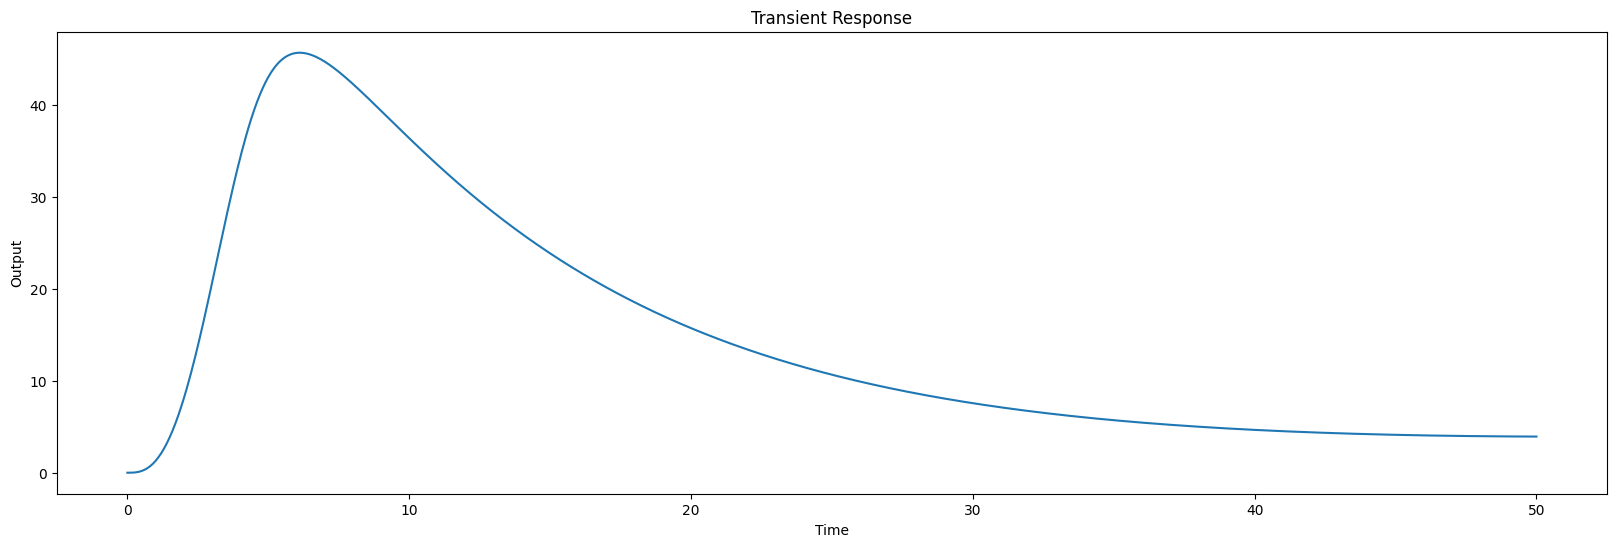

In [5]:
# Construct an IOCRN modeling a Gene Expression process controlled by the AIF controller
stoichiometry_reactants = np.array([[0, 1, 1, 0, 0, 0, 0], [0, 0, 0, 1, 0, 1, 0], [1, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 1]], dtype=np.int8)
stoichiometry_products = np.array([[1, 1, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 1, 0], [1, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0]], dtype=np.int8)
k = 1; k_1 = 1; gamma_1 = 1; gamma_2 = 0.1; mu = 10; theta = 1; eta = 0.1
parameters = np.array([k, k_1, gamma_1, gamma_2, mu, theta, eta], dtype=np.float32)
input_influence_matrix = np.array([[0, 0, 0, 0, 1, 0, 0]], dtype=np.int8)
outputs = np.array([2], dtype=np.int8)
IOCRN_AIF = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, parameters, input_influence_matrix, outputs)
species = ['X_1', 'X_2', 'Z_1', 'Z_2']
inputs = ['u']
IOCRN_AIF.print_reactions(species, inputs)

# Transient Response for the AIF Controller
u = np.array([1])
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
time_horizon = np.linspace(0, t_final, 1000, dtype=np.float32)

tic = time.time()
outputs_AIF_transient = IOCRN_AIF.transient_response(u, initial_condition, time_horizon)
toc = time.time()
print('Simulation Time: %.2f' % (toc - tic))

plt.figure(figsize=(20, 6))
plt.subplot(1, 1, 1)
for i in range(len(outputs_AIF_transient)):
    plt.plot(time_horizon, outputs_AIF_transient[i])
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response')

print(np.linalg.norm(10 - outputs_AIF_transient[0]) / np.sqrt(len(outputs_AIF_transient[0])))

In [7]:
# Construct an IOCRN modeling a Gene Expression process controlled by the Second Order PID controller
stoichiometry_reactants = np.array([[0, 1, 1, 0, 0, 0, 0, 1, 0], [0, 0, 0, 1, 0, 1, 0, 1, 1], [1, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0]], dtype=np.int8)
stoichiometry_products = np.array([[1, 1, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 1, 0, 1, 1], [1, 0, 0, 0, 1, 0, 0, 0, 1], [0, 0, 0, 0, 0, 1, 0, 0, 0]], dtype=np.int8)
k = 1; k_1 = 1; gamma_1 = 1; gamma_2 = 0.1; mu = -1; theta = 1; eta = 0.1; gamma = -1; b = -1
parameters = np.array([k, k_1, gamma_1, gamma_2, mu, theta, eta, gamma, b], dtype=np.float32)
input_influence_matrix = np.array([[0, 0, 0, 0, 1, 0, 0, 0, 0]], dtype=np.int8)
outputs = np.array([2], dtype=np.int8)
IOCRN_APIDF2 = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, parameters, input_influence_matrix, outputs)
species = ['X_1', 'X_2', 'Z_1', 'Z_2']
inputs = ['u']
IOCRN_APIDF2.print_reactions(species, inputs)

Inputs: ['u']
Species: ['X_1', 'X_2', 'Z_1', 'Z_2']
Output Species: ['X_2']
Reaction 1: Z_1 -> X_1 + Z_1 ; Rate Constant: 1.0
Reaction 2: X_1 -> X_1 + X_2 ; Rate Constant: 1.0
Reaction 3: X_1 -> 0 ; Rate Constant: 1.0
Reaction 4: X_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 5: 0 -> Z_1 ; Rate Constant: -1.0u
Reaction 6: X_2 -> X_2 + Z_2 ; Rate Constant: 1.0
Reaction 7: Z_1 + Z_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 8: X_1 + X_2 -> X_2 ; Rate Constant: -1.0
Reaction 9: X_2 -> X_2 + Z_1 ; Rate Constant: -1.0


In [8]:
# Construct the parameter grid
N_parameters = 3
param_1 = np.linspace(k, k, N_grid, dtype=np.float32)
param_2 = np.linspace(k_1, k_1, N_grid, dtype=np.float32)
param_3 = np.linspace(gamma_1, gamma_1, N_grid, dtype=np.float32)
param_4 = np.linspace(gamma_2, gamma_2, N_grid,  dtype=np.float32)
param_5 = np.linspace(5, 15, N_grid, dtype=np.float32)
param_6 = np.linspace(theta, theta, N_grid, dtype=np.float32)
param_7 = np.linspace(eta, eta, N_grid, dtype=np.float32)
param_8 = np.linspace(0.01, 1, N_grid,  dtype=np.float32)
param_9 = np.linspace(0, 1, N_grid,  dtype=np.float32)
parameter_grid = np.stack([param_1, param_2, param_3, param_4, param_5, param_6, param_7, param_8, param_9], axis=0)

In [9]:
# Construct the Parameter Sequence Generator
MyPSG = ParameterSequenceGenerator(IOCRN_APIDF2, parameter_grid, LSTM_hidden_size=128, FFNN_hidden_size=128, FFNN_num_layers=5, num_samples=N_samples).to(device)

In [10]:
# Design the loss function
def Performance_Metric(self, r, y):
    return np.linalg.norm(r - y) / np.sqrt(len(y))

def compute_loss(self, r, initial_condition, time_horizon, h0, c0, manifold_dim):
    indices, total_logP, total_entropy, h, c = self.forward(h0, c0, manifold_dim)
    parameter = self.map_index_to_parameter(indices, self.parameter_grid)
    loss_for_each_sample = []
    for p in parameter.T:
        self.IOCRN.parameters = p
        y = self.IOCRN.transient_response(u, initial_condition, time_horizon)
        e = self.Performance_Metric(r, y[0])
        loss_for_each_sample.append(e)
    loss_for_each_sample = torch.tensor(loss_for_each_sample).to(h0)
    loss_mean = torch.mean(loss_for_each_sample)
    return loss_for_each_sample, loss_mean, total_logP, total_entropy, parameter
MyPSG.Performance_Metric = types.MethodType(Performance_Metric, MyPSG)
MyPSG.compute_loss = types.MethodType(compute_loss, MyPSG)

In [11]:
# Train the parameter generator
r = 10
time_horizon = np.linspace(0, t_final, 100, dtype=np.float32)
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
manifold_dim = 0
h0 = torch.ones(MyPSG.num_samples, MyPSG.LSTM_hidden_size).float().to(device)
c0 = torch.ones(MyPSG.num_samples, MyPSG.LSTM_hidden_size).float().to(device)
optimizer = torch.optim.Adam(MyPSG.parameters(), lr=learning_rate)
tic = time.time()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    loss_for_each_sample, loss_mean, total_logPs, total_entropy, parameters = MyPSG.compute_loss(r, initial_condition, time_horizon, h0, c0, manifold_dim)
    entropy_mean = torch.mean(total_entropy)
    loss_for_gradient = torch.mean(loss_for_each_sample * total_logPs) - entropy_weight * entropy_mean - torch.mean(entropy_weight * total_entropy.detach() * total_logPs)
    loss_for_gradient.backward()
    optimizer.step()
    if epoch % 1 == 0:
        print('Epoch: %d, Mean Loss: %.4f, Entropy: %.4f, Entropy Weight: %.4f' % (epoch, loss_mean.item(), entropy_mean.item(), entropy_weight))
    if epoch % entropy_schedule == 0 and epoch != 0:
        entropy_weight = max(entropy_weight * entropy_update_coefficient, minimum_entropy_weight)
toc = time.time()
print('Training Time: %.2f' % (toc - tic))

Epoch: 0, Mean Loss: 21.0626, Entropy: 39.1045, Entropy Weight: 0.5000


KeyboardInterrupt: 

[1.         1.         1.         0.1        8.67347    1.
 0.1        0.41408163 0.30612245]
Simulation Time: 0.00


Text(0.5, 1.0, 'Transient Response')

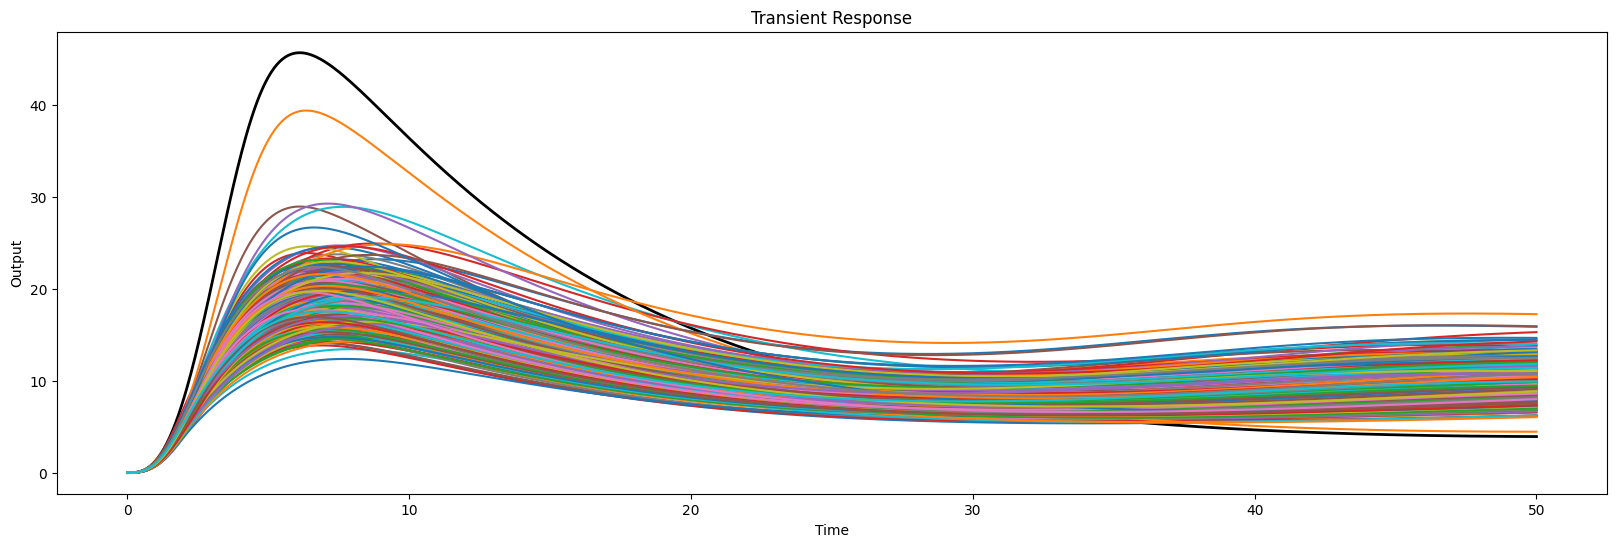

In [46]:
# Test the trained model
MyPSG.num_samples = 500
h0 = torch.ones(MyPSG.num_samples, MyPSG.LSTM_hidden_size).float()
c0 = torch.ones(MyPSG.num_samples, MyPSG.LSTM_hidden_size).float()
indices, _, _ = MyPSG(h0, c0, manifold_dim)
parameters = MyPSG.map_index_to_parameter(indices, parameter_grid)
print(parameters[:,1])

# Transient Response for the AIF Controller
u = np.array([1])
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
time_horizon = np.linspace(0, t_final, 1000, dtype=np.float32)

tic = time.time()

toc = time.time()
print('Simulation Time: %.2f' % (toc - tic))

plt.figure(figsize=(20, 6))
plt.subplot(1, 1, 1)
plt.plot(time_horizon, outputs_AIF_transient[0], label='AIF', color='black', linewidth=2)
for i in range(500):
    IOCRN_APIDF2_Trained = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, parameters[:,i], input_influence_matrix, outputs)
    outputs_transient = IOCRN_APIDF2_Trained.transient_response(u, initial_condition, time_horizon)
    plt.plot(time_horizon, outputs_transient[0], label=f"APIDF2', (mu, b, gamma, J, r) = ({parameters[4,i]:.2f}, {parameters[8,i]:.2f}, {parameters[7,i]:.2f}, {Performance_Metric(IOCRN_APIDF2_Trained, r, outputs_transient[0]):.2f}), {parameters[4,i]/(1 - parameters[8,i]):.2f}")
    # plt.legend()
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response')

[1.         1.         1.         0.1        6.9387755  1.
 0.1        0.41408163 0.30612245]


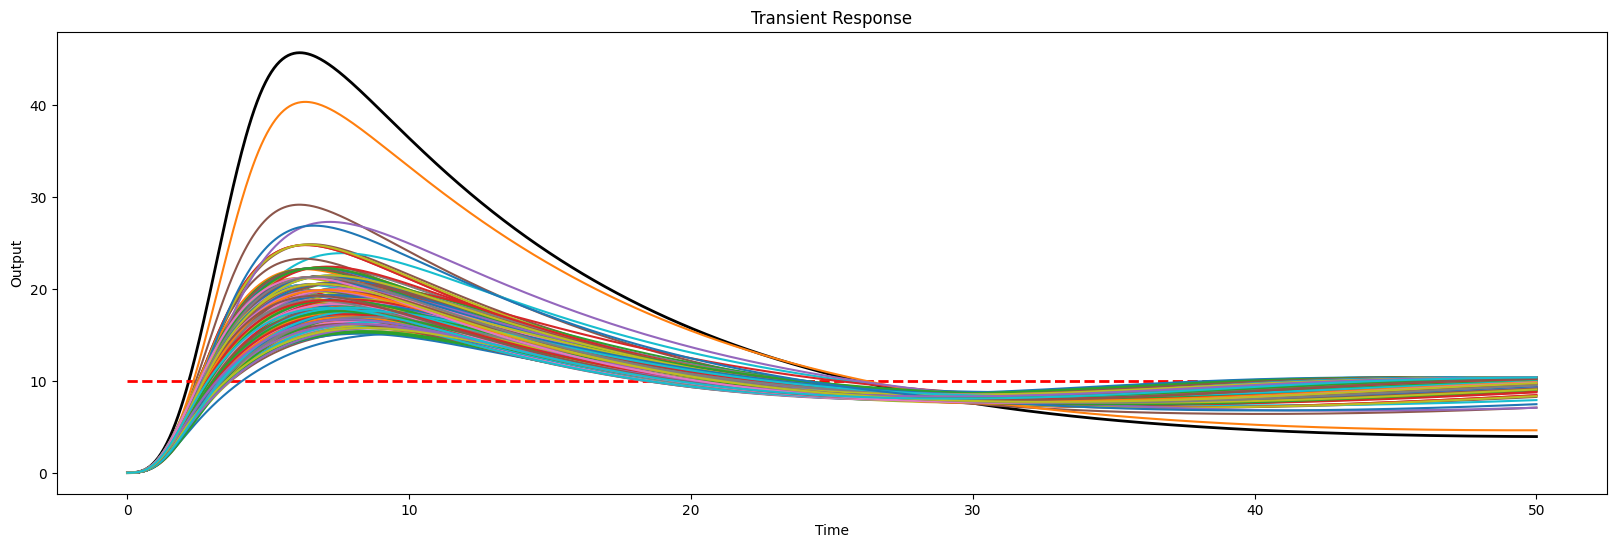

In [47]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 1, 1)
plt.plot(time_horizon, outputs_AIF_transient[0], label='AIF', color='black', linewidth=2)
plt.hlines(r, 0, t_final, label='Reference', color='red', linewidth=2, linestyles='dashed')
for i in range(500):
    IOCRN_APIDF2_Trained = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, parameters[:,i], input_influence_matrix, outputs)
    mu = r * (1 - parameters[8,i])
    IOCRN_APIDF2_Trained.parameters[4] = mu
    outputs_transient = IOCRN_APIDF2_Trained.transient_response(u, initial_condition, time_horizon)
    plt.plot(time_horizon, outputs_transient[0], label=f"APIDF2', (mu, b, gamma, J, r) = ({parameters[4,i]:.2f}, {parameters[8,i]:.2f}, {parameters[7,i]:.2f}, {Performance_Metric(IOCRN_APIDF2_Trained, r, outputs_transient[0]):.2f}), {parameters[4,i]/(1 - parameters[8,i]):.2f}")
    # plt.legend()
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response')
print(parameters[:,1])